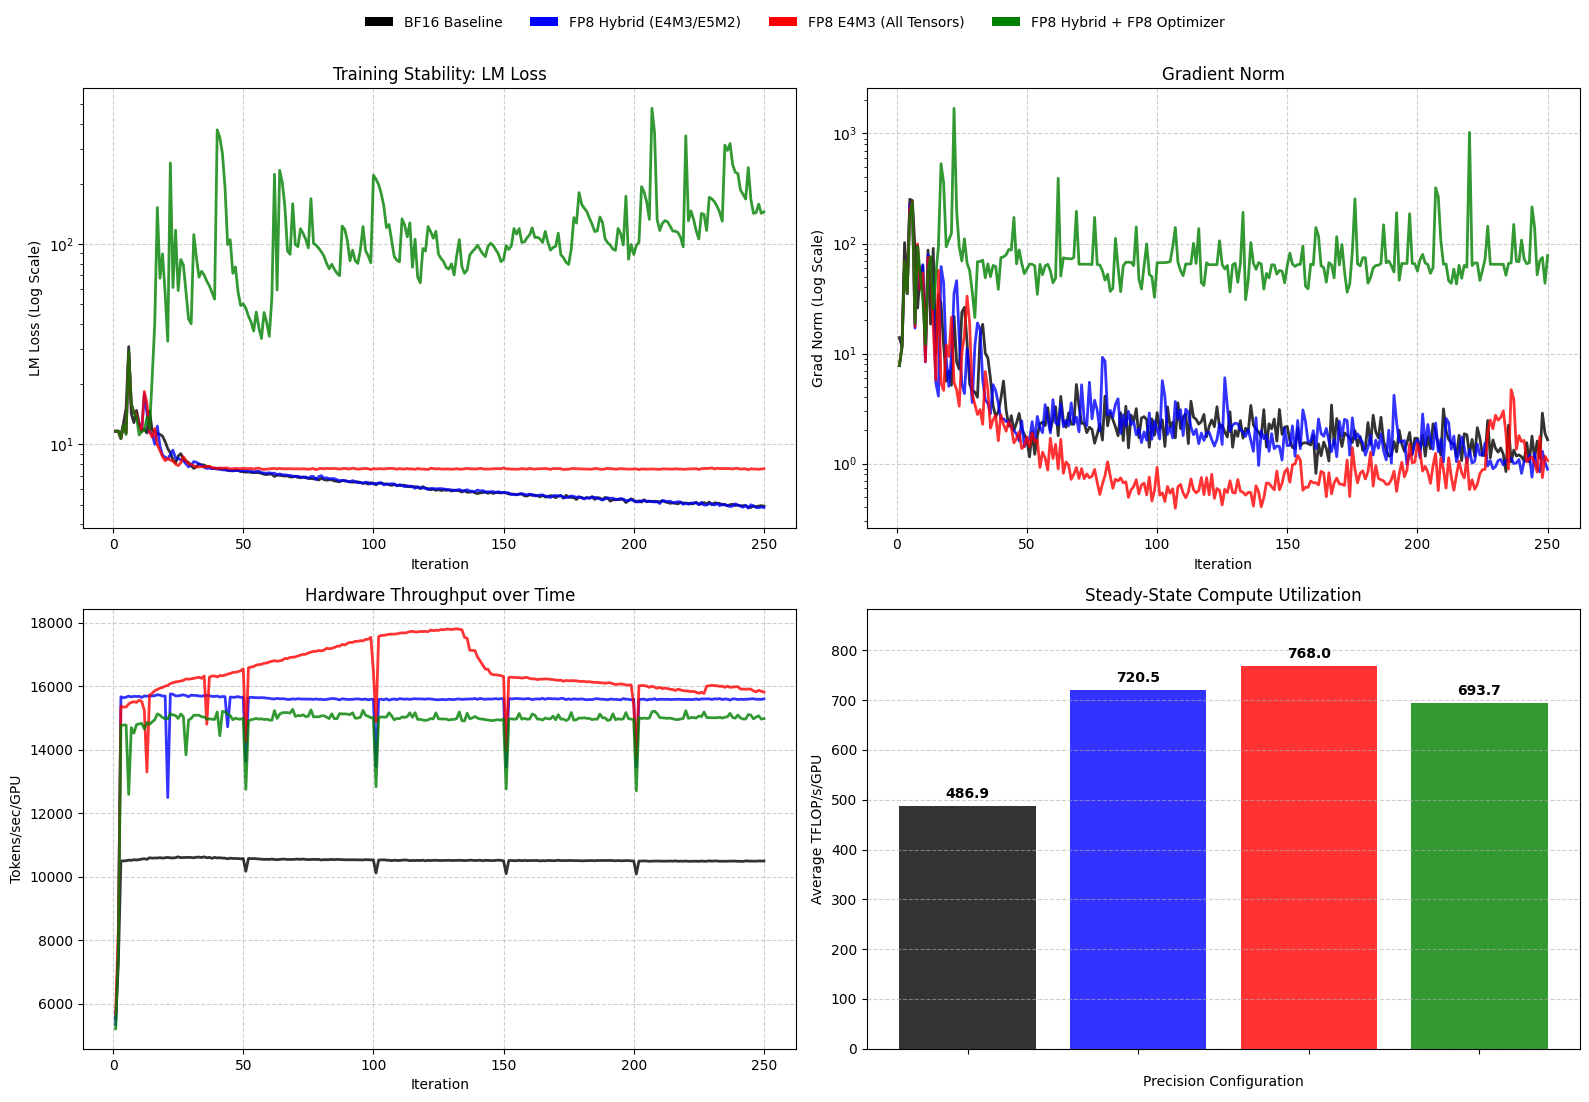

In [31]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch


BASE = Path("backlog")

logs = {
    "BF16 Baseline": {
        "path": BASE / "gipfel-train-8b-250s-4n-baseline-35min-1975423.log",
        "color": "black",
    },
    "FP8 Hybrid (E4M3/E5M2)": {
        "path": BASE / "gipfel-train-8b-250s-4n-hybrid-35min-1996684.log",
        "color": "blue",
    },
    "FP8 E4M3 (All Tensors)": {
        "path": BASE / "gipfel-train-8b-250s-4n-E4M3_only-35min-1996685.log",
        "color": "red",
    },
    "FP8 Hybrid + FP8 Optimizer": {
        "path": BASE / "gipfel-train-8b-250s-4n-FP8_stress-35min-1996686.log",
        "color": "green",
    },
}

log_pattern = re.compile(
    r"iteration\s+(?P<iteration>\d+)/.*?"
    r"throughput per GPU \(TFLOP/s/GPU\):\s+(?P<tflops>[\d\.]+).*?"
    r"tokens/sec/GPU:\s+(?P<tokens_sec>[\d\.]+).*?"
    r"lm loss:\s+(?P<lm_loss>[\d\.E\+\-]+).*?"
    r"grad norm:\s+(?P<grad_norm>[\d\.]+)"
)

data = []

for run_name, cfg in logs.items():
    filepath = cfg["path"]

    try:
        with open(filepath, "r") as f:
            for line in f:
                match = log_pattern.search(line)
                if match:
                    data.append({
                        "Run": run_name,
                        "Iteration": int(match.group("iteration")),
                        "TFLOPs": float(match.group("tflops")),
                        "Tokens/Sec": float(match.group("tokens_sec")),
                        "LM Loss": float(match.group("lm_loss")),
                        "Grad Norm": float(match.group("grad_norm")),
                    })

    except FileNotFoundError:
        print(f"Warning: Could not find {filepath}")

df = pd.DataFrame(data)

if df.empty:
    raise ValueError("No log data parsed. Check paths and log format.")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# fig.suptitle(
#     "Megatron-LM Precision Ablation Study",
#     fontsize=18,
#     fontweight="bold",
#     y=0.95,
# )

# Plot A: LM Loss
ax1 = axes[0, 0]
for run_name, cfg in logs.items():
    subset = df[df["Run"] == run_name]
    if subset.empty:
        continue
    ax1.plot(
        subset["Iteration"],
        subset["LM Loss"],
        label=run_name,
        color=cfg["color"],
        alpha=0.8,
        linewidth=2,
    )

ax1.set_title("Training Stability: LM Loss")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("LM Loss (Log Scale)")
ax1.set_yscale("log")
ax1.grid(True, linestyle="--", alpha=0.6)
# ax1.legend()
handles, labels = ax1.get_legend_handles_labels()


# Plot B: Gradient Norm
ax2 = axes[0, 1]
for run_name, cfg in logs.items():
    subset = df[df["Run"] == run_name]
    if subset.empty:
        continue
    ax2.plot(
        subset["Iteration"],
        subset["Grad Norm"],
        label=run_name,
        color=cfg["color"],
        alpha=0.8,
        linewidth=2,
    )

ax2.set_title("Gradient Norm")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Grad Norm (Log Scale)")
ax2.set_yscale("log")
ax2.grid(True, linestyle="--", alpha=0.6)
# ax2.legend()

# Plot C: Tokens/sec/GPU
ax3 = axes[1, 0]
for run_name, cfg in logs.items():
    subset = df[df["Run"] == run_name]
    if subset.empty:
        continue
    ax3.plot(
        subset["Iteration"],
        subset["Tokens/Sec"],
        label=run_name,
        color=cfg["color"],
        alpha=0.8,
        linewidth=2,
    )

ax3.set_title("Hardware Throughput over Time")
ax3.set_xlabel("Iteration")
ax3.set_ylabel("Tokens/sec/GPU")
ax3.grid(True, linestyle="--", alpha=0.6)
# ax3.legend()

# Plot D: Average TFLOPs after warmup
ax4 = axes[1, 1]

steady_state_df = df[df["Iteration"] > 50]
avg_tflops = steady_state_df.groupby("Run")["TFLOPs"].mean()

run_order = [run for run in logs if run in avg_tflops.index]
values = [avg_tflops[run] for run in run_order]
bar_colors = [logs[run]["color"] for run in run_order]

bars = ax4.bar(range(len(run_order)), values, color=bar_colors, alpha=0.8)

# remove specific run names
ax4.set_xticks(range(len(run_order)))
ax4.set_xticklabels([])

# general label instead
ax4.set_xlabel("Precision Configuration",labelpad=12)

ax4.set_title("Steady-State Compute Utilization")
ax4.set_ylabel("Average TFLOP/s/GPU")
ax4.set_ylim(0, max(values) * 1.15)
ax4.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 10,
        f"{yval:.1f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

from matplotlib.patches import Patch

handles = [
    Patch(facecolor=cfg["color"], edgecolor='none', label=run_name)
    for run_name, cfg in logs.items()
]

# for ax in [ax1,ax2,ax3]:
#     ax.axvspan(
#         200,
#         250,
#         color="gray",
#         alpha=0.15,
#     )

fig.legend(
    handles=handles,
    labels=labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, .92),
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()